
  ♔ THE CHESS MARKET — NSE Backtest
  Your code = your army
  The market = the chessboard

♟  Potential pawns loaded: 2224

♟  Loading processed board from cache...
♟  2218 stocks ready

♔  King's treasury: ₹100,000
♟  Max pawns on board: 6
🏟  Trading days (turns): 2471

Starting the game...

  Turn 500/2471  |  Pawns on board: 6  |  King's wealth: ₹218,817
  Turn 1000/2471  |  Pawns on board: 6  |  King's wealth: ₹167,956
  Turn 1500/2471  |  Pawns on board: 6  |  King's wealth: ₹469,839
  Turn 2000/2471  |  Pawns on board: 6  |  King's wealth: ₹1,466,000

  ♔ GAME OVER — FINAL RESULTS
  Period         : 2016-05-05 → 2026-05-05
  ♔ Starting treasury : ₹100,000
  ♔ Ending treasury   : ₹3,488,563
  Total Return   : 3388.6%
  CAGR           : 42.7%
  Max Drawdown   : -64.0%
  Sharpe Ratio   : 0.80
  Total Trades   : 1108

  ♟ Win Rate       : 34.2%
  ♟ Avg Win        : ₹17,620
  ♟ Avg Loss       : ₹-5,058
  ♟ Risk/Reward    : 3.48
  ♟ Avg Hold (days): 19
  ♟ Best Trade     : ₹837,972
  

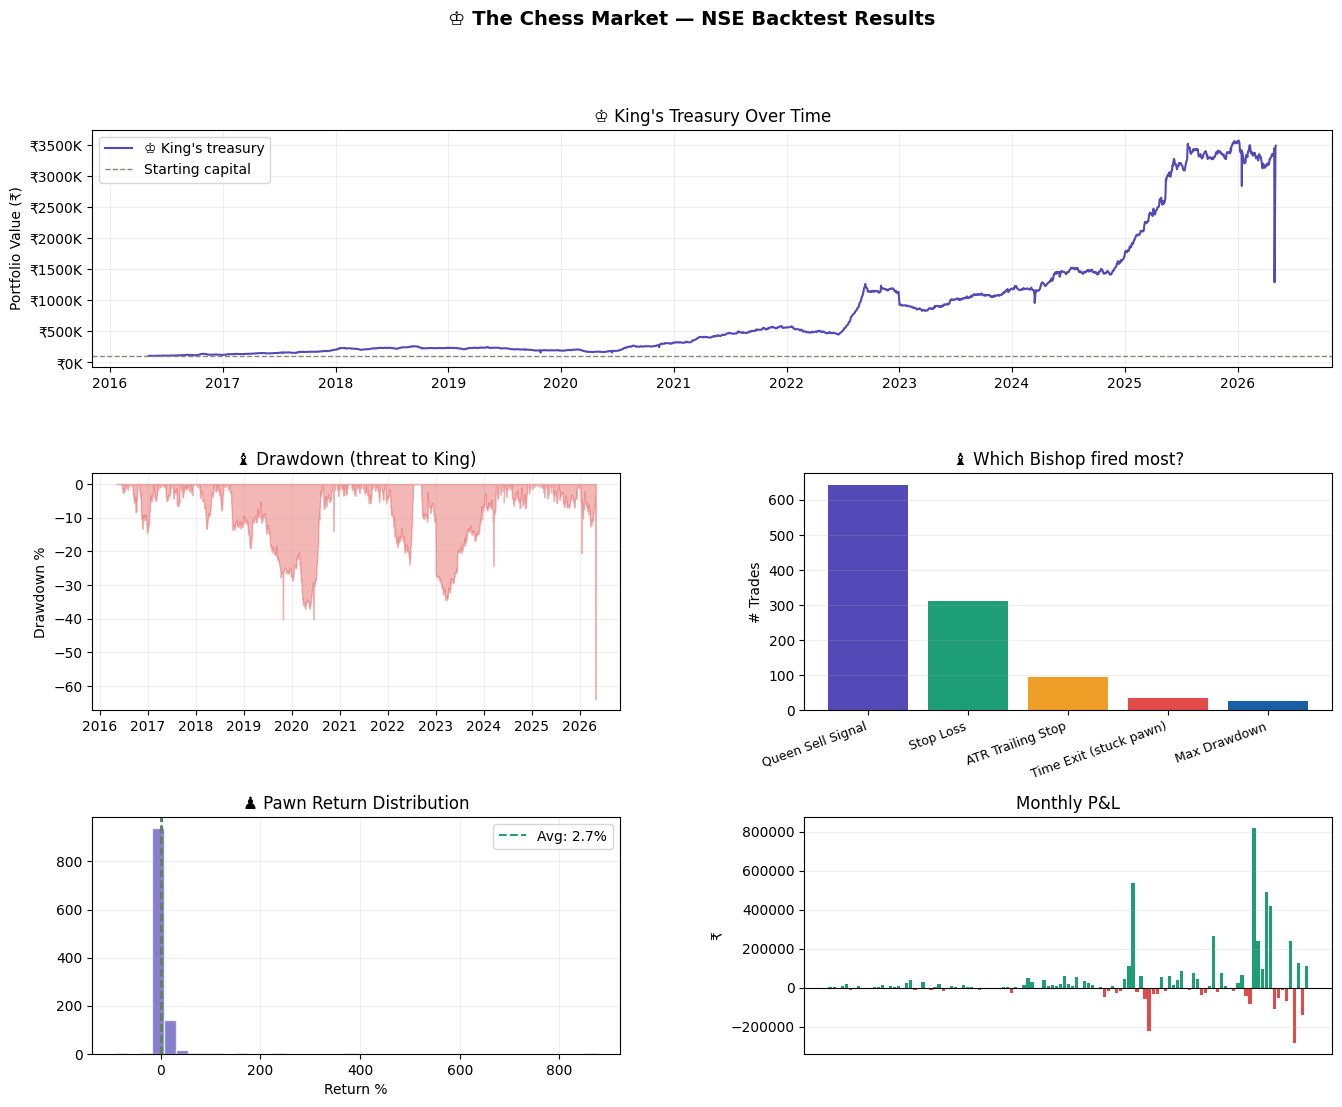

In [2]:
"""
=============================================================
  THE CHESS MARKET — NSE Backtest
  ─────────────────────────────────────────────────────────
  PIECES:
    ♔ King     = Your capital (protect at all costs)
    ♛ Queen    = UTBot signal (scans all 2000 stocks daily)
    ♝ Bishops  = Stop loss + ATR trailing + drawdown + time guard
    ♞ Knights  = Candidate scanner + volatility ranker
    ♜ Rooks    = Position manager + capital deployer
    ♟ Pawns    = Individual stock positions (max 20 on board)

  BOARD:
    2000+ NSE stocks = 2000 squares
    Each trading day = one turn
    Green square     = UTBot buy signal
    Red square       = UTBot sell signal / exit triggered
    Amber square     = Held position (pawn on this square)
=============================================================
"""

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
import pickle
import time
from concurrent.futures import ThreadPoolExecutor, as_completed

# ─────────────────────────────────────────────
#  ♔ KING SETTINGS  (protect these at all costs)
# ─────────────────────────────────────────────
INITIAL_CAPITAL     = 100_000   # King's treasury
LOOKBACK_PERIOD     = "10y"

# ─────────────────────────────────────────────
#  ♝ BISHOP SETTINGS  (defence rules)
# ─────────────────────────────────────────────
STOP_LOSS_PCT       = 0.04      # Bishop 1: hard stop 4% below entry
ATR_STOP_MULT       = 4.0       # Bishop 2: ATR trailing stop multiplier
MAX_DRAWDOWN_PCT    = 0.10      # Bishop 3: max fall from peak
HOLDING_DAYS_LIMIT  = 40       # Bishop 4: exit if held this many days...
MIN_HOLDING_RETURN  = 0.99      # ...and return is below this (99% = -1%)

# ─────────────────────────────────────────────
#  ♜ ROOK SETTINGS  (deployment rules)
# ─────────────────────────────────────────────
MAX_POSITIONS       = 6        # max pawns on the board at once

# ─────────────────────────────────────────────
#  ♛ QUEEN SETTINGS  (UTBot signal)
# ─────────────────────────────────────────────
ATR_PERIOD          = 14        # Queen's lookback for ATR

# ─────────────────────────────────────────────
#  CACHE
# ─────────────────────────────────────────────
CACHE_FILE          = "price_cache.pkl"
PROCESSED_CACHE     = "processed_chess.pkl"
USE_CACHE           = True
MAX_WORKERS         = 20

# ─────────────────────────────────────────────
#  ♟ LOAD PAWNS  (NSE stock universe)
# ─────────────────────────────────────────────
def load_nse_tickers():
    """Load all NSE stocks — these are your potential pawns."""
    df      = pd.read_csv("data/EQUITY_L.csv")
    symbols = df["SYMBOL"].dropna().astype(str).str.strip().unique().tolist()
    tickers = [s + ".NS" for s in symbols if "&" not in s]
    return tickers

# ─────────────────────────────────────────────
#  TIMEZONE FIX
# ─────────────────────────────────────────────
def normalize_index(df):
    idx = df.index
    if hasattr(idx, "tz") and idx.tz is not None:
        idx = idx.tz_convert("UTC").tz_localize(None)
    df.index = idx.normalize()
    return df

# ─────────────────────────────────────────────
#  ♛ QUEEN  (UTBot signal engine)
#  She scans the board every day and marks
#  green squares (buy) and red squares (sell)
# ─────────────────────────────────────────────
def compute_utbot(df):
    """
    The Queen's intelligence:
    - trend = +1 (green square) → price above lower band
    - trend = -1 (red square)   → price below upper band
    - buy  = trend flips -1 → +1  (Queen says ADVANCE)
    - sell = trend flips +1 → -1  (Queen says RETREAT)
    """
    df    = df.copy()
    close = df["Close"]
    high  = df["High"]
    low   = df["Low"]

    # True Range
    tr = np.maximum(
        high - low,
        np.maximum(
            (high - close.shift()).abs(),
            (low  - close.shift()).abs()
        )
    )

    # ATR (Queen's range sensor)
    df["atr"]   = tr.rolling(ATR_PERIOD).mean()
    df["upper"] = close - df["atr"]     # lower bound for uptrend
    df["lower"] = close + df["atr"]     # upper bound for downtrend

    # Trend detection
    trend = [1]
    for i in range(1, len(df)):
        if   close.iloc[i] > df["lower"].iloc[i-1]: trend.append(1)
        elif close.iloc[i] < df["upper"].iloc[i-1]: trend.append(-1)
        else:                                        trend.append(trend[-1])

    df["trend"]      = trend
    df["buy"]        = (df["trend"] == 1)  & (df["trend"].shift() == -1)
    df["sell"]       = (df["trend"] == -1) & (df["trend"].shift() == 1)

    # Knight's volatility score (used to rank candidates)
    df["volatility"] = close.pct_change(fill_method=None).rolling(20).std()

    return df

# ─────────────────────────────────────────────
#  DOWNLOAD + PROCESS DATA
# ─────────────────────────────────────────────
def load_all_data(tickers):
    """
    Download price history for all pawns.
    Cached after first run — second run is instant.
    """
    if USE_CACHE and os.path.exists(PROCESSED_CACHE):
        print("♟  Loading processed board from cache...")
        with open(PROCESSED_CACHE, "rb") as f:
            data = pickle.load(f)
        print(f"♟  {len(data)} stocks ready\n")
        return data

    # Download raw OHLCV
    if USE_CACHE and os.path.exists(CACHE_FILE):
        print("♟  Loading raw price cache...")
        price_data = pd.read_pickle(CACHE_FILE)
    else:
        print(f"♟  Downloading {len(tickers)} stocks from Yahoo Finance...")
        t0 = time.time()
        price_data = yf.download(
            tickers,
            period=LOOKBACK_PERIOD,
            group_by="ticker",
            auto_adjust=True,
            threads=True,
            progress=True
        )
        price_data.to_pickle(CACHE_FILE)
        print(f"♟  Downloaded in {(time.time()-t0)/60:.1f} min\n")

    # Apply Queen's signals to every stock
    print("♛  Queen scanning all stocks (computing UTBot)...")

    def process_ticker(ticker):
        try:
            df = price_data[ticker].dropna()
            if df.empty or len(df) < 60:
                return None
            if isinstance(df.columns, pd.MultiIndex):
                df.columns = df.columns.get_level_values(0)
            df = compute_utbot(df)
            df = normalize_index(df)
            return ticker, df
        except:
            return None

    all_data = {}
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as ex:
        for result in ex.map(process_ticker, tickers):
            if result is not None:
                ticker, df = result
                all_data[ticker] = df

    print(f"♛  Queen marked {len(all_data)} stocks with signals\n")

    with open(PROCESSED_CACHE, "wb") as f:
        pickle.dump(all_data, f)

    return all_data

# ─────────────────────────────────────────────
#  THE GAME  (main backtest loop)
# ─────────────────────────────────────────────
def play_the_game(all_data):
    """
    Each iteration = one trading day = one chess turn.

    Turn order every day:
      1. ♝ Bishops check all held pawns → exit if rules triggered
      2. ♛ Queen scans board → find today's green squares
      3. ♞ Knights rank candidates → volatility score
      4. ♜ Rooks deploy pawns → send capital to top squares
      5. ♔ King counts wealth → update equity curve
    """
    cash           = float(INITIAL_CAPITAL)
    open_positions = {}     # pawns currently on the board
    trade_log      = []
    equity_curve   = []
    date_index     = []

    # Normalize all indices (timezone fix)
    for ticker in list(all_data.keys()):
        all_data[ticker] = normalize_index(all_data[ticker])

    all_dates = sorted(set(
        d for df in all_data.values() for d in df.index
    ))

    print(f"♔  King's treasury: ₹{INITIAL_CAPITAL:,.0f}")
    print(f"♟  Max pawns on board: {MAX_POSITIONS}")
    print(f"🏟  Trading days (turns): {len(all_dates)}\n")
    print("Starting the game...\n")

    for turn, current_date in enumerate(all_dates):

        # ── ♝ BISHOPS: check every held pawn ──────────────
        for ticker in list(open_positions.keys()):
            df  = all_data[ticker]
            if current_date not in df.index:
                continue

            row = df.loc[current_date]
            pos = open_positions[ticker]

            # Update highest price seen (Bishop 2 needs this)
            pos["highest_price"] = max(
                pos["highest_price"], float(row["Close"])
            )

            # Bishop 1: hard stop loss
            stop_price = pos["entry_price"] * (1 - STOP_LOSS_PCT)

            # Bishop 2: ATR trailing stop (moves up with price)
            atr_stop   = pos["highest_price"] - (
                float(row["atr"]) * ATR_STOP_MULT
            )

            # Bishop 3: max drawdown from peak
            drawdown   = (
                pos["highest_price"] - float(row["Close"])
            ) / pos["highest_price"]

            # Bishop 4: time-based exit (stuck pawn)
            holding_days   = (current_date - pos["entry_date"]).days
            holding_return = float(row["Close"]) / pos["entry_price"]

            # Which Bishop fires first?
            if (
                holding_days >= HOLDING_DAYS_LIMIT
                and holding_return < MIN_HOLDING_RETURN
            ):
                exit_reason = "♝ Time Exit (stuck pawn)"

            elif float(row["Close"]) <= stop_price:
                exit_reason = "♝ Stop Loss"

            elif float(row["Close"]) <= atr_stop:
                exit_reason = "♝ ATR Trailing Stop"

            elif drawdown >= MAX_DRAWDOWN_PCT:
                exit_reason = "♝ Max Drawdown"

            elif bool(row["sell"]):
                exit_reason = "♛ Queen Sell Signal"

            else:
                continue   # pawn stays on board

            # Execute exit — pawn sacrificed, capital returned to King
            exit_price = float(row["Close"])
            proceeds   = pos["shares"] * exit_price
            profit     = proceeds - pos["invested"]
            cash      += proceeds

            trade_log.append({
                "Stock":         ticker,
                "Entry Date":    pos["entry_date"],
                "Exit Date":     current_date,
                "Entry Price":   round(pos["entry_price"], 2),
                "Exit Price":    round(exit_price, 2),
                "Shares":        round(pos["shares"], 4),
                "Invested ₹":   round(pos["invested"], 2),
                "Profit ₹":     round(profit, 2),
                "Return %":      round((exit_price/pos["entry_price"]-1)*100, 2),
                "Holding Days":  (current_date - pos["entry_date"]).days,
                "Exit Reason":   exit_reason,
            })

            del open_positions[ticker]

        # ── ♛ QUEEN + ♞ KNIGHTS: scan + rank ──────────────
        available_slots = MAX_POSITIONS - len(open_positions)

        if available_slots > 0 and cash > 0:

            # Queen marks green squares, Knights score them
            candidates = []

            for ticker, df in all_data.items():
                if ticker in open_positions:
                    continue
                if current_date not in df.index:
                    continue

                row = df.loc[current_date]

                # Skip if volatility unavailable
                if pd.isna(row["volatility"]) or row["volatility"] == 0:
                    continue

                # ♛ Queen: is this a green square today?
                if bool(row["buy"]):
                    # ♞ Knight: score = lower volatility = safer advance
                    score = 1.0 / float(row["volatility"])
                    candidates.append((ticker, score, row))

            # Knights rank: best score moves first
            candidates.sort(key=lambda x: x[1], reverse=True)

            # ── ♜ ROOKS: deploy pawns ─────────────────────
            for ticker, score, row in candidates[:available_slots]:
                remaining  = MAX_POSITIONS - len(open_positions)
                if remaining <= 0 or cash <= 0:
                    break

                # Rook divides King's treasury equally
                allocation = cash / remaining
                price      = float(row["Close"])
                shares     = allocation / price
                cash      -= allocation

                open_positions[ticker] = {
                    "entry_date":    current_date,
                    "entry_price":   price,
                    "highest_price": price,
                    "shares":        shares,
                    "invested":      allocation,
                }

        # ── ♔ KING: count wealth at end of each turn ──────
        portfolio_value = cash
        for ticker, pos in open_positions.items():
            df = all_data[ticker]
            if current_date in df.index:
                portfolio_value += (
                    pos["shares"] * float(df.loc[current_date]["Close"])
                )

        equity_curve.append(portfolio_value)
        date_index.append(current_date)

        # Progress
        if (turn+1) % 500 == 0:
            print(f"  Turn {turn+1}/{len(all_dates)}  |  "
                  f"Pawns on board: {len(open_positions)}  |  "
                  f"King's wealth: ₹{portfolio_value:,.0f}")

    return pd.DataFrame(trade_log), equity_curve, date_index

# ─────────────────────────────────────────────
#  ♔ END OF GAME — RESULTS
# ─────────────────────────────────────────────
def game_over(trades, equity_curve, date_index):
    print("\n" + "="*58)
    print("  ♔ GAME OVER — FINAL RESULTS")
    print("="*58)

    if not equity_curve:
        print("  ERROR: No equity curve — check data loading.")
        return

    eq    = np.array(equity_curve)
    final = eq[-1]
    years = (date_index[-1] - date_index[0]).days / 365.25

    # Performance metrics
    cagr    = ((final/INITIAL_CAPITAL)**(1/years) - 1)*100 if years>0 else 0
    peak    = np.maximum.accumulate(eq)
    mdd     = ((eq - peak)/peak).min() * 100
    ret_s   = pd.Series(eq).pct_change().dropna()
    sharpe  = (ret_s.mean()/ret_s.std()*np.sqrt(252)) if ret_s.std()>0 else 0
    total_r = (final/INITIAL_CAPITAL - 1)*100

    print(f"  Period         : {date_index[0].date()} → {date_index[-1].date()}")
    print(f"  ♔ Starting treasury : ₹{INITIAL_CAPITAL:,.0f}")
    print(f"  ♔ Ending treasury   : ₹{final:,.0f}")
    print(f"  Total Return   : {total_r:.1f}%")
    print(f"  CAGR           : {cagr:.1f}%")
    print(f"  Max Drawdown   : {mdd:.1f}%")
    print(f"  Sharpe Ratio   : {sharpe:.2f}")
    print(f"  Total Trades   : {len(trades)}")

    if not trades.empty:
        wins      = trades[trades["Profit ₹"] > 0]
        losses    = trades[trades["Profit ₹"] < 0]
        win_rate  = len(wins)/len(trades)*100
        avg_win   = wins["Profit ₹"].mean()   if len(wins)   > 0 else 0
        avg_loss  = losses["Profit ₹"].mean() if len(losses) > 0 else 0
        rr        = abs(avg_win/avg_loss)      if avg_loss != 0 else 0
        avg_hold  = trades["Holding Days"].mean()

        print(f"\n  ♟ Win Rate       : {win_rate:.1f}%")
        print(f"  ♟ Avg Win        : ₹{avg_win:,.0f}")
        print(f"  ♟ Avg Loss       : ₹{avg_loss:,.0f}")
        print(f"  ♟ Risk/Reward    : {rr:.2f}")
        print(f"  ♟ Avg Hold (days): {avg_hold:.0f}")
        print(f"  ♟ Best Trade     : ₹{trades['Profit ₹'].max():,.0f}")
        print(f"  ♟ Worst Trade    : ₹{trades['Profit ₹'].min():,.0f}")

        print("\n  ♝ Exit Reasons (which Bishop fired most):")
        for reason, cnt in trades["Exit Reason"].value_counts().items():
            avg_r = trades[trades["Exit Reason"]==reason]["Return %"].mean()
            print(f"    {reason:<32} {cnt:>4} trades | avg: {avg_r:.1f}%")

    print("="*58)

# ─────────────────────────────────────────────
#  SAVE TRADE LOG
# ─────────────────────────────────────────────
def save_trade_log(trades):
    if trades.empty:
        print("No trades to save.")
        return

    trades = trades.sort_values("Exit Date").copy()
    trades["Cumulative Profit"] = trades["Profit ₹"].cumsum()
    trades["Portfolio Equity"]  = INITIAL_CAPITAL + trades["Cumulative Profit"]

    # Strip timezone (Excel fix)
    for col in ["Entry Date", "Exit Date"]:
        if col in trades.columns:
            trades[col] = pd.to_datetime(trades[col])
            if trades[col].dt.tz is not None:
                trades[col] = trades[col].dt.tz_localize(None)

    try:
        trades.to_excel("chess_market_trades.xlsx", index=False)
        print("\n♟  Trade log saved: chess_market_trades.xlsx")
    except:
        trades.to_csv("chess_market_trades.csv", index=False)
        print("\n♟  Trade log saved: chess_market_trades.csv")

# ─────────────────────────────────────────────
#  PLOT THE BATTLEFIELD
# ─────────────────────────────────────────────
def plot_battlefield(equity_curve, date_index, trades):
    if not equity_curve:
        return

    fig = plt.figure(figsize=(16, 12))
    gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)
    fig.suptitle(
        "♔ The Chess Market — NSE Backtest Results",
        fontsize=14, fontweight="bold"
    )

    # 1. Equity curve (King's treasury over time)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(date_index, equity_curve, color="#534AB7", lw=1.5,
             label="♔ King's treasury")
    ax1.axhline(INITIAL_CAPITAL, color="#888780", lw=1,
                linestyle="--", label="Starting capital")
    ax1.set_title("♔ King's Treasury Over Time")
    ax1.set_ylabel("Portfolio Value (₹)")
    ax1.legend(); ax1.grid(alpha=0.2)
    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"₹{x/1000:.0f}K")
    )

    if not trades.empty:

        # 2. Drawdown (how close to checkmate)
        ax2 = fig.add_subplot(gs[1, 0])
        eq   = np.array(equity_curve)
        peak = np.maximum.accumulate(eq)
        dd   = (eq - peak) / peak * 100
        ax2.fill_between(date_index, dd, 0, color="#E24B4A", alpha=0.4)
        ax2.set_title("♝ Drawdown (threat to King)")
        ax2.set_ylabel("Drawdown %"); ax2.grid(alpha=0.2)

        # 3. Exit reasons (which Bishop fired)
        ax3 = fig.add_subplot(gs[1, 1])
        reason_counts = trades["Exit Reason"].value_counts()
        colors = ["#534AB7","#1D9E75","#EF9F27","#E24B4A","#185FA5"]
        bars   = ax3.bar(
            range(len(reason_counts)),
            reason_counts.values,
            color=colors[:len(reason_counts)]
        )
        ax3.set_title("♝ Which Bishop fired most?")
        ax3.set_xticks(range(len(reason_counts)))
        ax3.set_xticklabels(
            [r.replace("♝ ","").replace("♛ ","")
             for r in reason_counts.index],
            rotation=20, ha="right", fontsize=9
        )
        ax3.set_ylabel("# Trades"); ax3.grid(alpha=0.2, axis="y")

        # 4. Return distribution (how well pawns performed)
        ax4 = fig.add_subplot(gs[2, 0])
        ax4.hist(
            trades["Return %"], bins=40,
            color="#534AB7", alpha=0.7, edgecolor="white"
        )
        ax4.axvline(0, color="#E24B4A", lw=1.5, linestyle="--")
        ax4.axvline(
            trades["Return %"].mean(), color="#1D9E75", lw=1.5,
            linestyle="--",
            label=f'Avg: {trades["Return %"].mean():.1f}%'
        )
        ax4.set_title("♟ Pawn Return Distribution")
        ax4.set_xlabel("Return %")
        ax4.legend(); ax4.grid(alpha=0.2)

        # 5. Monthly P&L
        ax5 = fig.add_subplot(gs[2, 1])
        trades["Exit Date"] = pd.to_datetime(trades["Exit Date"])
        monthly = trades.groupby(
            trades["Exit Date"].dt.to_period("M")
        )["Profit ₹"].sum()
        bar_colors = [
            "#1D9E75" if v >= 0 else "#E24B4A"
            for v in monthly.values
        ]
        ax5.bar(range(len(monthly)), monthly.values, color=bar_colors)
        ax5.set_title("Monthly P&L")
        ax5.set_ylabel("₹")
        ax5.axhline(0, color="black", lw=0.8)
        ax5.set_xticks([]); ax5.grid(alpha=0.2, axis="y")

    plt.savefig("chess_market_results.png", dpi=150, bbox_inches="tight")
    print("♔  Chart saved: chess_market_results.png")
    plt.show()

# ─────────────────────────────────────────────
#  MAIN  — start the game
# ─────────────────────────────────────────────
if __name__ == "__main__":

    print("\n" + "="*58)
    print("  ♔ THE CHESS MARKET — NSE Backtest")
    print("  Your code = your army")
    print("  The market = the chessboard")
    print("="*58 + "\n")

    # Load pawns (NSE stocks)
    tickers = load_nse_tickers()
    print(f"♟  Potential pawns loaded: {len(tickers)}\n")

    # Download + process board
    all_data = load_all_data(tickers)

    if not all_data:
        print("ERROR: No data. Check data/EQUITY_L.csv")
        exit(1)

    # Play the game
    trades, equity_curve, date_index = play_the_game(all_data)

    # Results
    game_over(trades, equity_curve, date_index)

    # Save
    save_trade_log(trades)

    # Plot
    plot_battlefield(equity_curve, date_index, trades)